# Assessing Accuracy of the Tide Predictions of the Ocean State Ocean Model

Author of this document: Grace Kowalski
Edited by: Timothy Divoll

The purpose of this notebook is to use National Oceanic and Atmospheric Administration (NOAA) tide data to better understand the behavior of tides in the Narragansett Bay, as well as using Ocean State Ocean Model (OSOM) tide data to see how accurately the model is predicting the observed water level. This notebook is a great practice in organizing and visualzing data. There are various colorful plots being made to best visualize the findings. 

The observed water level data was collected from 9 tide gauges within the Narragansett Bay boundary from the National Oceanic and Atmospheric Administration’s Center for Operational Oceanographic Products and Services (NOAA CO-OPS) over the years 2004 to current. The NOAA CO-OPS gauges also had water level predicted by NOAA that we collected for the same locations and time period. The OSOM water level data was collected for the same 9 locations using the closest latitude and longitude points as the NOAA gauges, only for the year of 2017. All of this was collected and analyzed in meters.

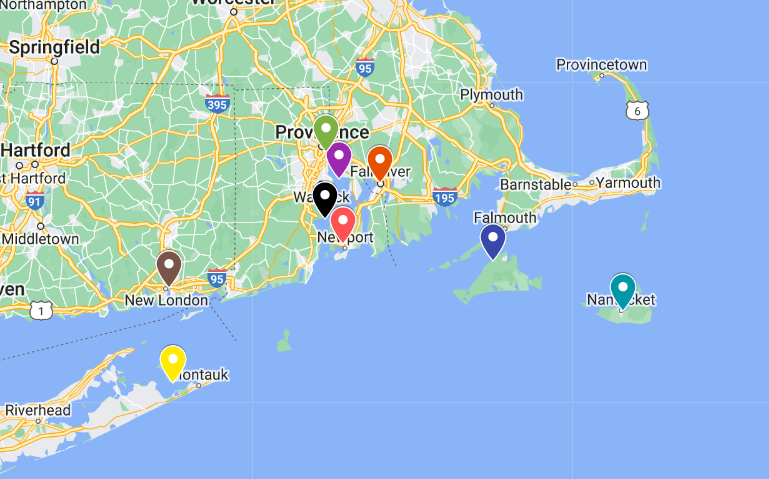

Firstly, we need to install and import the necessary packages to run the code.

In [ ]:
!pip install noaa_coops # this package sends requests to NOAA CO-OPS API
import pandas as pd
import noaa_coops
import matplotlib.pyplot as plt
from datetime import datetime
import numpy as np
import netCDF4 as nc
from netCDF4 import num2date, date2num, date2index

import warnings
warnings.filterwarnings('ignore')

### Manual data download
The following is an example of how to work with data downloaded from the NOAA webpage (https://tidesandcurrents.noaa.gov/stations.html?type=Water+Levels)

Next, we should read in all of the data we want to use. The data downloaded directly from the NOAA webpage is in comma-separated value form, so we write a function to specifically read in .csv files. From reading those files, the variables for time, predicted waterlevel, and verified waterlevel will be put into lists. These lists will store all of that data for plotting and further data manipulation.

In [2]:
#Define a function to read csv files and make a list of variables to be used
def readcsv(document):
    #Open the file and read it
    df = pd.read_csv(document ,na_values=["-"], skiprows=6)
    #Make three separate lists for the date, hour, and water level variables
    date=df['Date'].tolist()
    hour=df['Time (GMT)'].tolist()
    level=df['Verified (m)'].tolist()
    predicted=df['Predicted (m)']
    #Merge the date and hour lists
    time=[]
    for i in range(len(date)):
        time.append(date[i]+" "+ hour[i])
    return time, level, predicted

Now we can call this function to read in all the files. We have 9 files of hourly buoy data for each of the 9 stations.

In [ ]:
#Read in all the files
#Make sure to title all the lists so that they are different from each other
time_8447386, water_8447386, predicted_8447386 = readcsv("C:\\Users\\grace\\OneDrive\\Documents\\Brown_Data\\Tides\\CO-OPS_8447386_met.csv")
time_8447930, water_8447930, predicted_8447930 = readcsv("C:\\Users\\grace\\OneDrive\\Documents\\Brown_Data\\Tides\\CO-OPS_8447930_met.csv")
time_8449130, water_8449130, predicted_8449130 = readcsv("C:\\Users\\grace\\OneDrive\\Documents\\Brown_Data\\Tides\\CO-OPS_8449130_met.csv")
time_8452660, water_8452660, predicted_8452660 = readcsv("C:\\Users\\grace\\OneDrive\\Documents\\Brown_Data\\Tides\\CO-OPS_8452660_met.csv")
time_8452944, water_8452944, predicted_8452944 = readcsv("C:\\Users\\grace\\OneDrive\\Documents\\Brown_Data\\Tides\\CO-OPS_8452944_met.csv")
time_8454000, water_8454000, predicted_8454000 = readcsv("C:\\Users\\grace\\OneDrive\\Documents\\Brown_Data\\Tides\\CO-OPS_8454000_met.csv")
time_8454049, water_8454049, predicted_8454049 = readcsv("C:\\Users\\grace\\OneDrive\\Documents\\Brown_Data\\Tides\\CO-OPS_8454049_met.csv")
time_8461490, water_8461490, predicted_8461490 = readcsv("C:\\Users\\grace\\OneDrive\\Documents\\Brown_Data\\Tides\\CO-OPS_8461490_met.csv")
time_8510560, water_8510560, predicted_8510560 = readcsv("C:\\Users\\grace\\OneDrive\\Documents\\Brown_Data\\Tides\\CO-OPS_8510560_met.csv")

### Alternate direct data dowload - example
The next cell has code to extract the data directly from the NOAA CO-OPS API rather than downloading from the webpage. This block only shows two example stations and additional stations could be added.

In [123]:
# send a request to the CO-OPS API for Data Retrieval
# https://api.tidesandcurrents.noaa.gov/api/prod/
# MLLW = mean lower low water

station_list = [8461490, 8510560, 8447930, 8441930, 8452660, 8454049, 8447386, 8452944, 8454000]

# New London, CT example
new_london = noaa_coops.Station(station_list[0]) #use a different index for a different station
new_london_verified = new_london.get_data(
    begin_date = "20040101",
    end_date = "20040616",
    product = "water_level",
    datum = "MLLW",
    units = "metric",
    time_zone = "gmt",
    interval = "h")
new_london_predicted = new_london.get_data(
    begin_date = "20040101",
    end_date = "20040616",
    product = "predictions",
    datum = "MLLW",
    units = "metric",
    time_zone = "gmt",
    interval = "h")

# merge verified and predicted, then rename columns to match `readcsv` function
new_london_df = pd.merge(new_london_verified, new_london_predicted, on="date_time").drop(columns = ["sigma", "flags", "QC"]).rename(columns={"water_level": "Verified (m)", "predicted_wl": "Predicted (m)"}).reset_index()
new_london_df["Date"] = [d.date() for d in new_london_df["date_time"]]
new_london_df["Time (GMT)"] = [d.time() for d in new_london_df["date_time"]]


# Montauk, NY example
montauk = noaa_coops.Station(station_list[1])
montauk_verified = montauk.get_data(
    begin_date = "20040101",
    end_date = "20220616",
    product = "water_level",
    datum = "MLLW",
    units = "metric",
    time_zone = "gmt",
    interval = "h")
montauk_predicted = montauk.get_data(
    begin_date = "20040101",
    end_date = "20220616",
    product = "predictions",
    datum = "MLLW",
    units = "metric",
    time_zone = "gmt",
    interval = "h")

# merge verified and predicted, then rename columns to match `readcsv` function
montauk_df = pd.merge(montauk_verified, montauk_predicted, on="date_time").drop(columns = ["sigma", "flags", "QC"]).rename(columns={"water_level": "Verified (m)", "predicted_wl": "Predicted (m)"}).reset_index()
montauk_df["Date"] = [d.date() for d in montauk_df["date_time"]]
montauk_df["Time (GMT)"] = [d.time() for d in montauk_df["date_time"]]

In [124]:
new_london_df.head()

,date_time,Verified (m),Predicted (m),Date,Time (GMT)
0,2004-01-01 00:00:00,0.353,0.408,2004-01-01,00:00:00
1,2004-01-01 01:00:00,0.238,0.311,2004-01-01,01:00:00
2,2004-01-01 02:00:00,0.119,0.194,2004-01-01,02:00:00
3,2004-01-01 03:00:00,0.101,0.104,2004-01-01,03:00:00
4,2004-01-01 04:00:00,0.118,0.098,2004-01-01,04:00:00


In [125]:
montauk_df.tail()

,date_time,Verified (m),Predicted (m),Date,Time (GMT)
0,2004-01-01 00:00:00,0.230,0.308,2004-01-01,00:00:00
1,2004-01-01 01:00:00,0.145,0.243,2004-01-01,01:00:00
2,2004-01-01 02:00:00,0.100,0.165,2004-01-01,02:00:00
3,2004-01-01 03:00:00,0.102,0.119,2004-01-01,03:00:00
4,2004-01-01 04:00:00,0.149,0.140,2004-01-01,04:00:00


In [129]:
#Define a function to make a list of variables to be used
#Note: Only used with the direct download option
def readdata(document):
    #Open the file and read it
    df = document
    #Make three separate lists for the date, hour, and water level variables
    date=df['Date'].tolist()
    hour=df['Time (GMT)'].tolist()
    level=df['Verified (m)'].tolist()
    predicted=df['Predicted (m)']
    #Merge the date and hour lists
    time=df['date_time']
    #for i in range(len(date)):
    #    time.append(date[i]+" "+ hour[i])
    return time, level, predicted

In [130]:
time_8461490, water_8461490, predicted_8461490 = readdata(new_london_df)
time_8510560, water_8510560, predicted_8510560 = readdata(montauk_df)

The first plot we will make are weekly plots for each station. This can be done by using the lists we formed above and separating out the dates we want by using the year and month. The plot will be 4 subplots for each week of the month of interest. 

In [ ]:
#Define a function to plot each week in a month as a subplot
#The "time" variable is the list of time created above for the station of interest (choose any station)
#The "water_level" variable is the list of NOAA verified water level for that same station
#The "year" variable is the year of interest
#The "month" variable is the month of interest
#The 4 "title" variables are the title of each subplot
#The "file" variable is the pathway name to save the figure
def weeklyplots(time, water_level, year, month, title1, title2, title3, title4, file):
    #Create a list where it ends in only the year you want
    yr=[]
    yr_level=[]
    for k in range(len(time)):
        if year in time[k]:
            yr.append(time[k])
            yr_level.append(water_level[k])
    #Creat a list where the first part of the string is the month you want to only get that month
    mmyr=[]
    mmyr_water_str=[]
    for i in range(len(yr)):
        if yr[i].startswith(month):
            mmyr.append(yr[i])
            mmyr_water_str.append(yr_level[i])
    week1_str=[]
    week1_water_str=[]
    week2_str=[]
    week2_water_str=[]
    week3_str=[]
    week3_water_str=[]
    week4_str=[]
    week4_water_str=[]
    for j in range(len(mmyr)):
        #Say that if the date contains these days in the middle, that is week one. So days 1 through 7
        if "/1/" in mmyr[j] or "/2/" in mmyr[j] or "/3/" in mmyr[j] or "/4/" in mmyr[j] or "/5/" in mmyr[j] or "/6/" in mmyr[j] or "/7/" in mmyr[j]:
            week1_str.append(mmyr[j])
            week1_water_str.append(mmyr_water_str[j])
        #Days 8 through 14 are week 2
        elif "/8/" in mmyr[j] or "/9/" in mmyr[j] or "/10/" in mmyr[j] or "/11/" in mmyr[j] or "/12/" in mmyr[j] or "/13/" in mmyr[j] or "/14/" in mmyr[j]:
            week2_str.append(mmyr[j])
            week2_water_str.append(mmyr_water_str[j])  
        #Days 15 through 21 are week 3
        elif "/15/" in mmyr[j] or "/16/" in mmyr[j] or "/17/" in mmyr[j] or "/18/" in mmyr[j] or "/19/" in mmyr[j] or "/20/" in mmyr[j] or "/21/" in mmyr[j]:
            week3_str.append(mmyr[j])
            week3_water_str.append(mmyr_water_str[j])
        #Days 22 through 31 are week 4
        elif "/22/" in mmyr[j] or "/23/" in mmyr[j] or "/24/" in mmyr[j] or "/25/" in mmyr[j] or "/26/" in mmyr[j] or "/27/" in mmyr[j] or "/28/" in mmyr[j] or "/29/" in mmyr[j] or "/30/" in mmyr[j] or "/31/" in mmyr[j]:
            week4_str.append(mmyr[j])
            week4_water_str.append(mmyr_water_str[j])
    #Make the list of string dates into datetime
    week1=[]
    week2=[]
    week3=[]
    week4=[]
    for l in range(len(week1_str)):
        week1.append(datetime.strptime(week1_str[l], '%m/%d/%Y %H:%M'))
    for l in range(len(week2_str)):
        week2.append(datetime.strptime(week2_str[l], '%m/%d/%Y %H:%M'))
    for l in range(len(week3_str)):
        week3.append(datetime.strptime(week3_str[l], '%m/%d/%Y %H:%M'))
    for l in range(len(week4_str)):
        week4.append(datetime.strptime(week4_str[l], '%m/%d/%Y %H:%M'))
    #Make the list of weekly water level strings into floats
    week1_water=[]
    week2_water=[]
    week3_water=[]
    week4_water=[]
    for i in range(len(week1_water_str)):
        week1_water.append(float(week1_water_str[i]))
    for i in range(len(week2_water_str)):
        week2_water.append(float(week2_water_str[i]))
    for i in range(len(week3_water_str)):
        week3_water.append(float(week3_water_str[i]))
    for i in range(len(week4_water_str)):
        week4_water.append(float(week4_water_str[i]))
    #Making subplots. I want 4 vertical plots and for them to share a y-axis
    fig, axs=plt.subplots(4, figsize=(35,35), sharey = True)
    x1 = week1
    y1=week1_water
    x2 = week2
    y2=week2_water
    x3 = week3
    y3=week3_water
    x4 = week4
    y4=week4_water
    axs[0].plot(x1, y1)
    axs[1].plot(x2, y2)
    axs[2].plot(x3, y3)
    axs[3].plot(x4, y4)
    #Making title of each plot
    axs[0].set_title(title1, fontsize=20)
    axs[1].set_title(title2, fontsize=20)
    axs[2].set_title(title3, fontsize=20)
    axs[3].set_title(title4, fontsize=20)
    #Setting font of the axes
    axs[0].xaxis.set_tick_params(labelsize=18)
    axs[1].xaxis.set_tick_params(labelsize=18)
    axs[2].xaxis.set_tick_params(labelsize=18)
    axs[3].xaxis.set_tick_params(labelsize=18)
    axs[0].yaxis.set_tick_params(labelsize=18)
    axs[1].yaxis.set_tick_params(labelsize=18)
    axs[2].yaxis.set_tick_params(labelsize=18)
    axs[3].yaxis.set_tick_params(labelsize=18)
    #plt.show
    plt.savefig(file)
#Call the function to make the plots
#Making weekly plots for every month in 2006 at the 8447386 station
weeklyplots(time_8447386, water_8447386, "/2006", "1/", "January 2006 Week 1 8447386", "January 2006 Week 2 8447386", "January 2006 Week 3 8447386", "January 2006 Week 4 8447386", "C:\\Users\\grace\\OneDrive\\Documents\\Brown_Data\\Tide_Plots\\January 2006 Weekly 8447386.png")
weeklyplots(time_8447386, water_8447386, "/2006", "2/", "February 2006 Week 1 8447386", "February 2006 Week 2 8447386", "February 2006 Week 3 8447386", "February 2006 Week 4 8447386", "C:\\Users\\grace\\OneDrive\\Documents\\Brown_Data\\Tide_Plots\\February 2006 Weekly 8447386.png")
weeklyplots(time_8447386, water_8447386, "/2006", "3/", "March 2006 Week 1 8447386", "March 2006 Week 2 8447386", "March 2006 Week 3 8447386", "March 2006 Week 4 8447386", "C:\\Users\\grace\\OneDrive\\Documents\\Brown_Data\\Tide_Plots\\March 2006 Weekly 8447386.png")
weeklyplots(time_8447386, water_8447386, "/2006", "4/", "April 2006 Week 1 8447386", "April 2006 Week 2 8447386", "April 2006 Week 3 8447386", "April 2006 Week 4 8447386", "C:\\Users\\grace\\OneDrive\\Documents\\Brown_Data\\Tide_Plots\\April 2006 Weekly 8447386.png")
weeklyplots(time_8447386, water_8447386, "/2006", "5/", "May 2006 Week 1 8447386", "May 2006 Week 2 8447386", "May 2006 Week 3 8447386", "May 2006 Week 4 8447386", "C:\\Users\\grace\\OneDrive\\Documents\\Brown_Data\\Tide_Plots\\May 2006 Weekly 8447386.png")
weeklyplots(time_8447386, water_8447386, "/2006", "6/", "June 2006 Week 1 8447386", "June 2006 Week 2 8447386", "June 2006 Week 3 8447386", "June 2006 Week 4 8447386", "C:\\Users\\grace\\OneDrive\\Documents\\Brown_Data\\Tide_Plots\\June 2006 Weekly 8447386.png")
weeklyplots(time_8447386, water_8447386, "/2006", "7/", "July 2006 Week 1 8447386", "July 2006 Week 2 8447386", "July 2006 Week 3 8447386", "July 2006 Week 4 8447386", "C:\\Users\\grace\\OneDrive\\Documents\\Brown_Data\\Tide_Plots\\July 2006 Weekly 8447386.png")
weeklyplots(time_8447386, water_8447386, "/2006", "8/", "August 2006 Week 1 8447386", "August 2006 Week 2 8447386", "August 2006 Week 3 8447386", "August 2006 Week 4 8447386", "C:\\Users\\grace\\OneDrive\\Documents\\Brown_Data\\Tide_Plots\\August 2006 Weekly 8447386.png")
weeklyplots(time_8447386, water_8447386, "/2006", "9/", "September 2006 Week 1 8447386", "September 2006 Week 2 8447386", "September 2006 Week 3 8447386", "September 2006 Week 4 8447386", "C:\\Users\\grace\\OneDrive\\Documents\\Brown_Data\\Tide_Plots\\September 2006 Weekly 8447386.png")
weeklyplots(time_8447386, water_8447386, "/2006", "10/", "October 2006 Week 1 8447386", "October 2006 Week 2 8447386", "October 2006 Week 3 8447386", "October 2006 Week 4 8447386", "C:\\Users\\grace\\OneDrive\\Documents\\Brown_Data\\Tide_Plots\\October 2006 Weekly 8447386.png")
weeklyplots(time_8447386, water_8447386, "/2006", "11/", "November 2006 Week 1 8447386", "November 2006 Week 2 8447386", "November 2006 Week 3 8447386", "November 2006 Week 4 8447386", "C:\\Users\\grace\\OneDrive\\Documents\\Brown_Data\\Tide_Plots\\November 2006 Weekly 8447386.png")
weeklyplots(time_8447386, water_8447386, "/2006", "12/", "December 2006 Week 1 8447386", "December 2006 Week 2 8447386", "December 2006 Week 3 8447386", "December 2006 Week 4 8447386", "C:\\Users\\grace\\OneDrive\\Documents\\Brown_Data\\Tide_Plots\\December 2006 Weekly 8447386.png")

This is the kind of plot you can expect to see. It shows two high and low tides per day, and also how the tides change throughout the month.
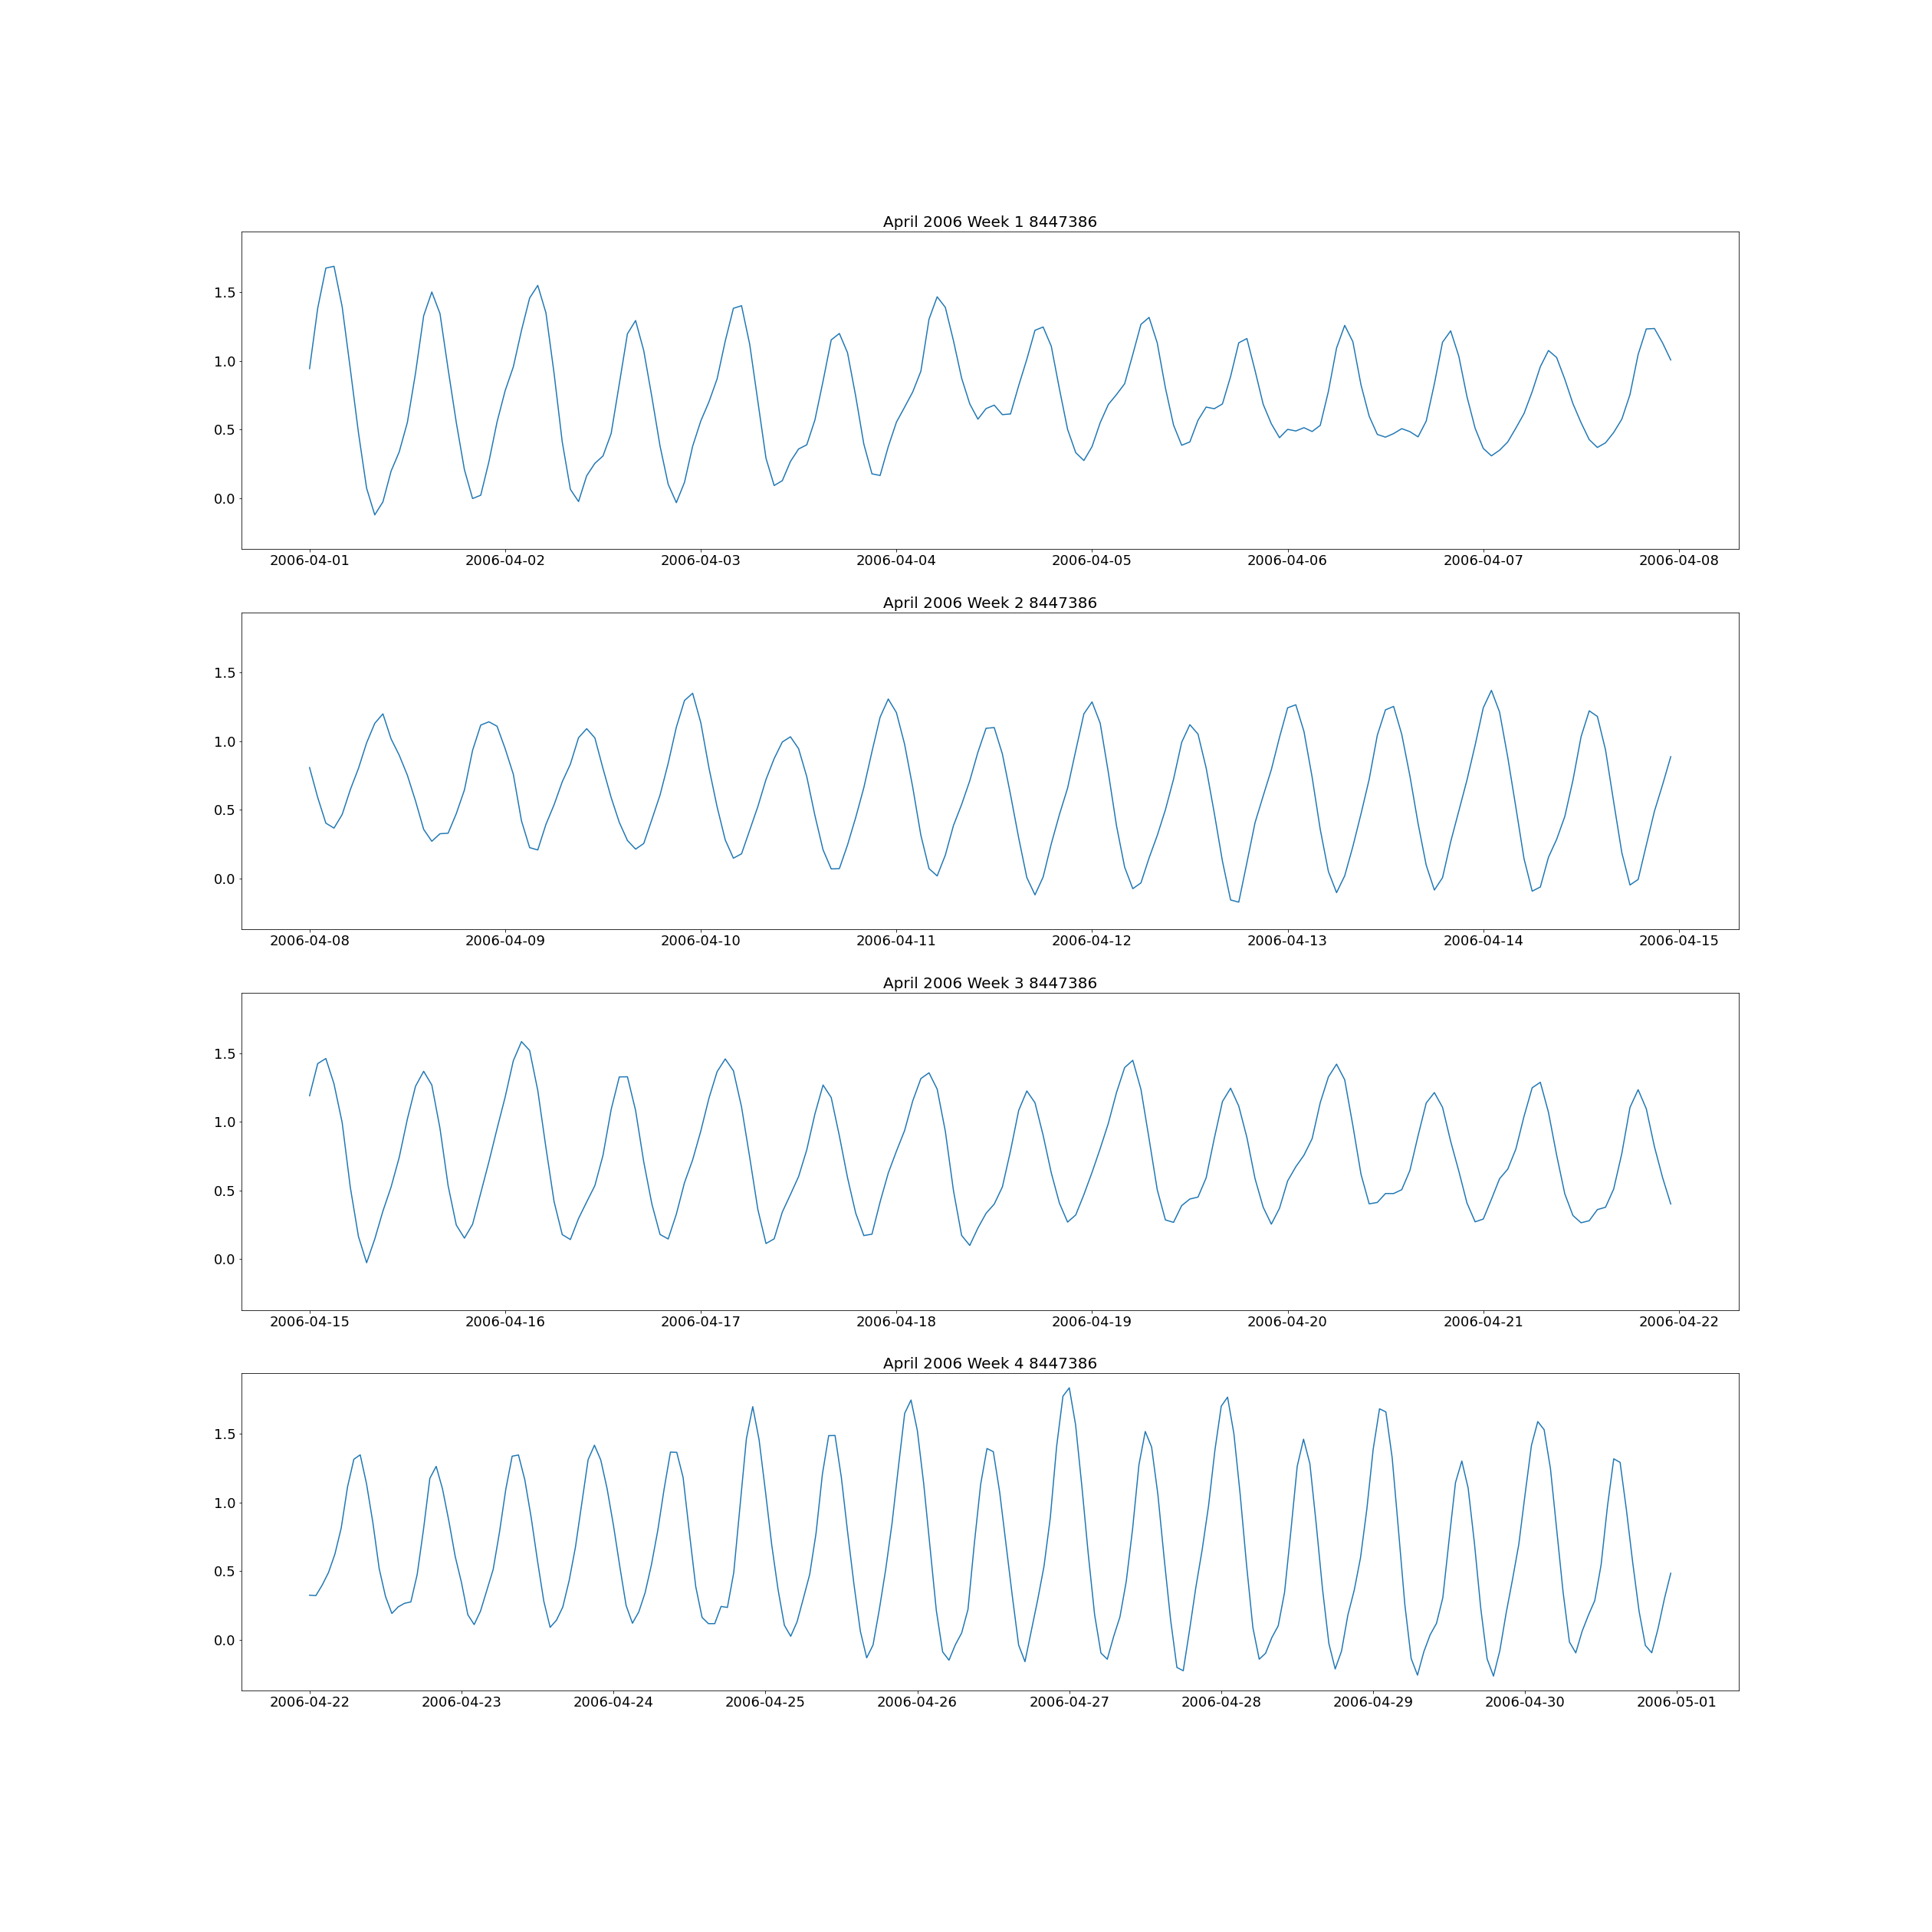

Similar weekly subplots can be made, but where each station is on the same plot rather than one at a time.

In [ ]:
#Making a plot to compare weekly water level of all buoys for May 2018
#First make all of the weekly data lists
week1_8447386, week1water_8447386, week2_8447386, week2water_8447386, week3_8447386, week3water_8447386, week4_8447386, week4water_8447386=weeklylist(time_8447386, water_8447386, "/2018", "5/")
week1_8447930, week1water_8447930, week2_8447930, week2water_8447930, week3_8447930, week3water_8447930, week4_8447930, week4water_8447930=weeklylist(time_8447930, water_8447930, "/2018", "5/")
week1_8449130, week1water_8449130, week2_8449130, week2water_8449130, week3_8449130, week3water_8449130, week4_8449130, week4water_8449130=weeklylist(time_8449130, water_8449130, "/2018", "5/")
week1_8452660, week1water_8452660, week2_8452660, week2water_8452660, week3_8452660, week3water_8452660, week4_8452660, week4water_8452660=weeklylist(time_8452660, water_8452660, "/2018", "5/")
week1_8452944, week1water_8452944, week2_8452944, week2water_8452944, week3_8452944, week3water_8452944, week4_8452944, week4water_8452944=weeklylist(time_8452944, water_8452944, "/2018", "5/")
week1_8454000, week1water_8454000, week2_8454000, week2water_8454000, week3_8454000, week3water_8454000, week4_8454000, week4water_8454000=weeklylist(time_8454000, water_8454000, "/2018", "5/")
week1_8454049, week1water_8454049, week2_8454049, week2water_8454049, week3_8454049, week3water_8454049, week4_8454049, week4water_8454049=weeklylist(time_8454049, water_8454049, "/2018", "5/")
week1_8461490, week1water_8461490, week2_8461490, week2water_8461490, week3_8461490, week3water_8461490, week4_8461490, week4water_8461490=weeklylist(time_8461490, water_8461490, "/2018", "5/")
week1_8510560, week1water_8510560, week2_8510560, week2water_8510560, week3_8510560, week3water_8510560, week4_8510560, week4water_8510560=weeklylist(time_8510560, water_8510560, "/2018", "5/")
#Start making subplots of the 4 weeks
fig, axs=plt.subplots(4, figsize=(35,35), sharey = True)
#Lines for the first week
axs[0].plot(week1_8447386, week1water_8447386, label="8447386", color='red')
axs[0].plot(week1_8447386, week1water_8447930, label="8447930", color='blue')
axs[0].plot(week1_8447386, week1water_8449130, label="8449130", color='cyan' )
axs[0].plot(week1_8447386, week1water_8452660, label="8452660", color='coral')
axs[0].plot(week1_8447386, week1water_8452944, label="8452944", color='purple')
axs[0].plot(week1_8447386, week1water_8454000, label="8454000", color='limegreen')
axs[0].plot(week1_8447386, week1water_8454049, label="8454049", color='black')
axs[0].plot(week1_8447386, week1water_8461490, label="8461490", color='brown')
axs[0].plot(week1_8447386, week1water_8510560, label="8510560", color='yellow')
#Lines for the second week
axs[1].plot(week1_8447386, week2water_8447386, label="8447386", color='red')
axs[1].plot(week1_8447386, week2water_8447930, label="8447930", color='blue')
axs[1].plot(week1_8447386, week2water_8449130, label="8449130", color='cyan')
axs[1].plot(week1_8447386, week2water_8452660, label="8452660", color='coral')
axs[1].plot(week1_8447386, week2water_8452944, label="8452944", color='purple')
axs[1].plot(week1_8447386, week2water_8454000, label="8454000", color='limegreen')
axs[1].plot(week1_8447386, week2water_8454049, label="8454049", color='black')
axs[1].plot(week1_8447386, week2water_8461490, label="8461490", color='brown')
axs[1].plot(week1_8447386, week2water_8510560, label="8510560", color='yellow')
#Week 3
axs[2].plot(week1_8447386, week3water_8447386, label="8447386", color='red')
axs[2].plot(week1_8447386, week3water_8447930, label="8447930", color='blue')
axs[2].plot(week1_8447386, week3water_8449130, label="8449130", color='cyan')
axs[2].plot(week1_8447386, week3water_8452660, label="8452660", color='coral')
axs[2].plot(week1_8447386, week3water_8452944, label="8452944", color='purple')
axs[2].plot(week1_8447386, week3water_8454000, label="8454000", color='limegreen')
axs[2].plot(week1_8447386, week3water_8454049, label="8454049", color='black')
axs[2].plot(week1_8447386, week3water_8461490, label="8461490", color='brown')
axs[2].plot(week1_8447386, week3water_8510560, label="8510560", color='yellow')
#Week 4
axs[3].plot(week4_8447386, week4water_8447386, label="8447386", color='red')
axs[3].plot(week4_8447386, week4water_8447930, label="8447930", color='blue')
axs[3].plot(week4_8447386, week4water_8449130, label="8449130", color='cyan')
axs[3].plot(week4_8447386, week4water_8452660, label="8452660", color='coral')
axs[3].plot(week4_8447386, week4water_8452944, label="8452944", color='purple')
axs[3].plot(week4_8447386, week4water_8454000, label="8454000", color='limegreen')
axs[3].plot(week4_8447386, week4water_8454049, label="8454049", color='black')
axs[3].plot(week4_8447386, week4water_8461490, label="8461490", color='brown')
axs[3].plot(week4_8447386, week4water_8510560, label="8510560", color='yellow')
#Making title of each plot
axs[0].set_title("Week 1 May 2018", fontsize=20)
axs[1].set_title("Week 2 May 2018", fontsize=20)
axs[2].set_title("Week 3 May 2018", fontsize=20)
axs[3].set_title("Week 4 May 2018", fontsize=20)
#Setting font of the axes
axs[0].xaxis.set_tick_params(labelsize=18)
axs[1].xaxis.set_tick_params(labelsize=18)
axs[2].xaxis.set_tick_params(labelsize=18)
axs[3].xaxis.set_tick_params(labelsize=18)
axs[0].yaxis.set_tick_params(labelsize=18)
axs[1].yaxis.set_tick_params(labelsize=18)
axs[2].yaxis.set_tick_params(labelsize=18)
axs[3].yaxis.set_tick_params(labelsize=18)
plt.legend()

The plot is the one below. The colors of each line correspond to the map of the buoys above. It can be seen that the 4 tide gauges that are farther into the ocean (8449130, 8447930, 8510560, 8461490) have a lower overall amplitude of water level, which corresponds to known tidal behavior. The tide gauges that are closer together and directly in the bay have higher peaks that tend to peak around the same time. It can also be seen that the water level peaks move in a counterclockwise direction.
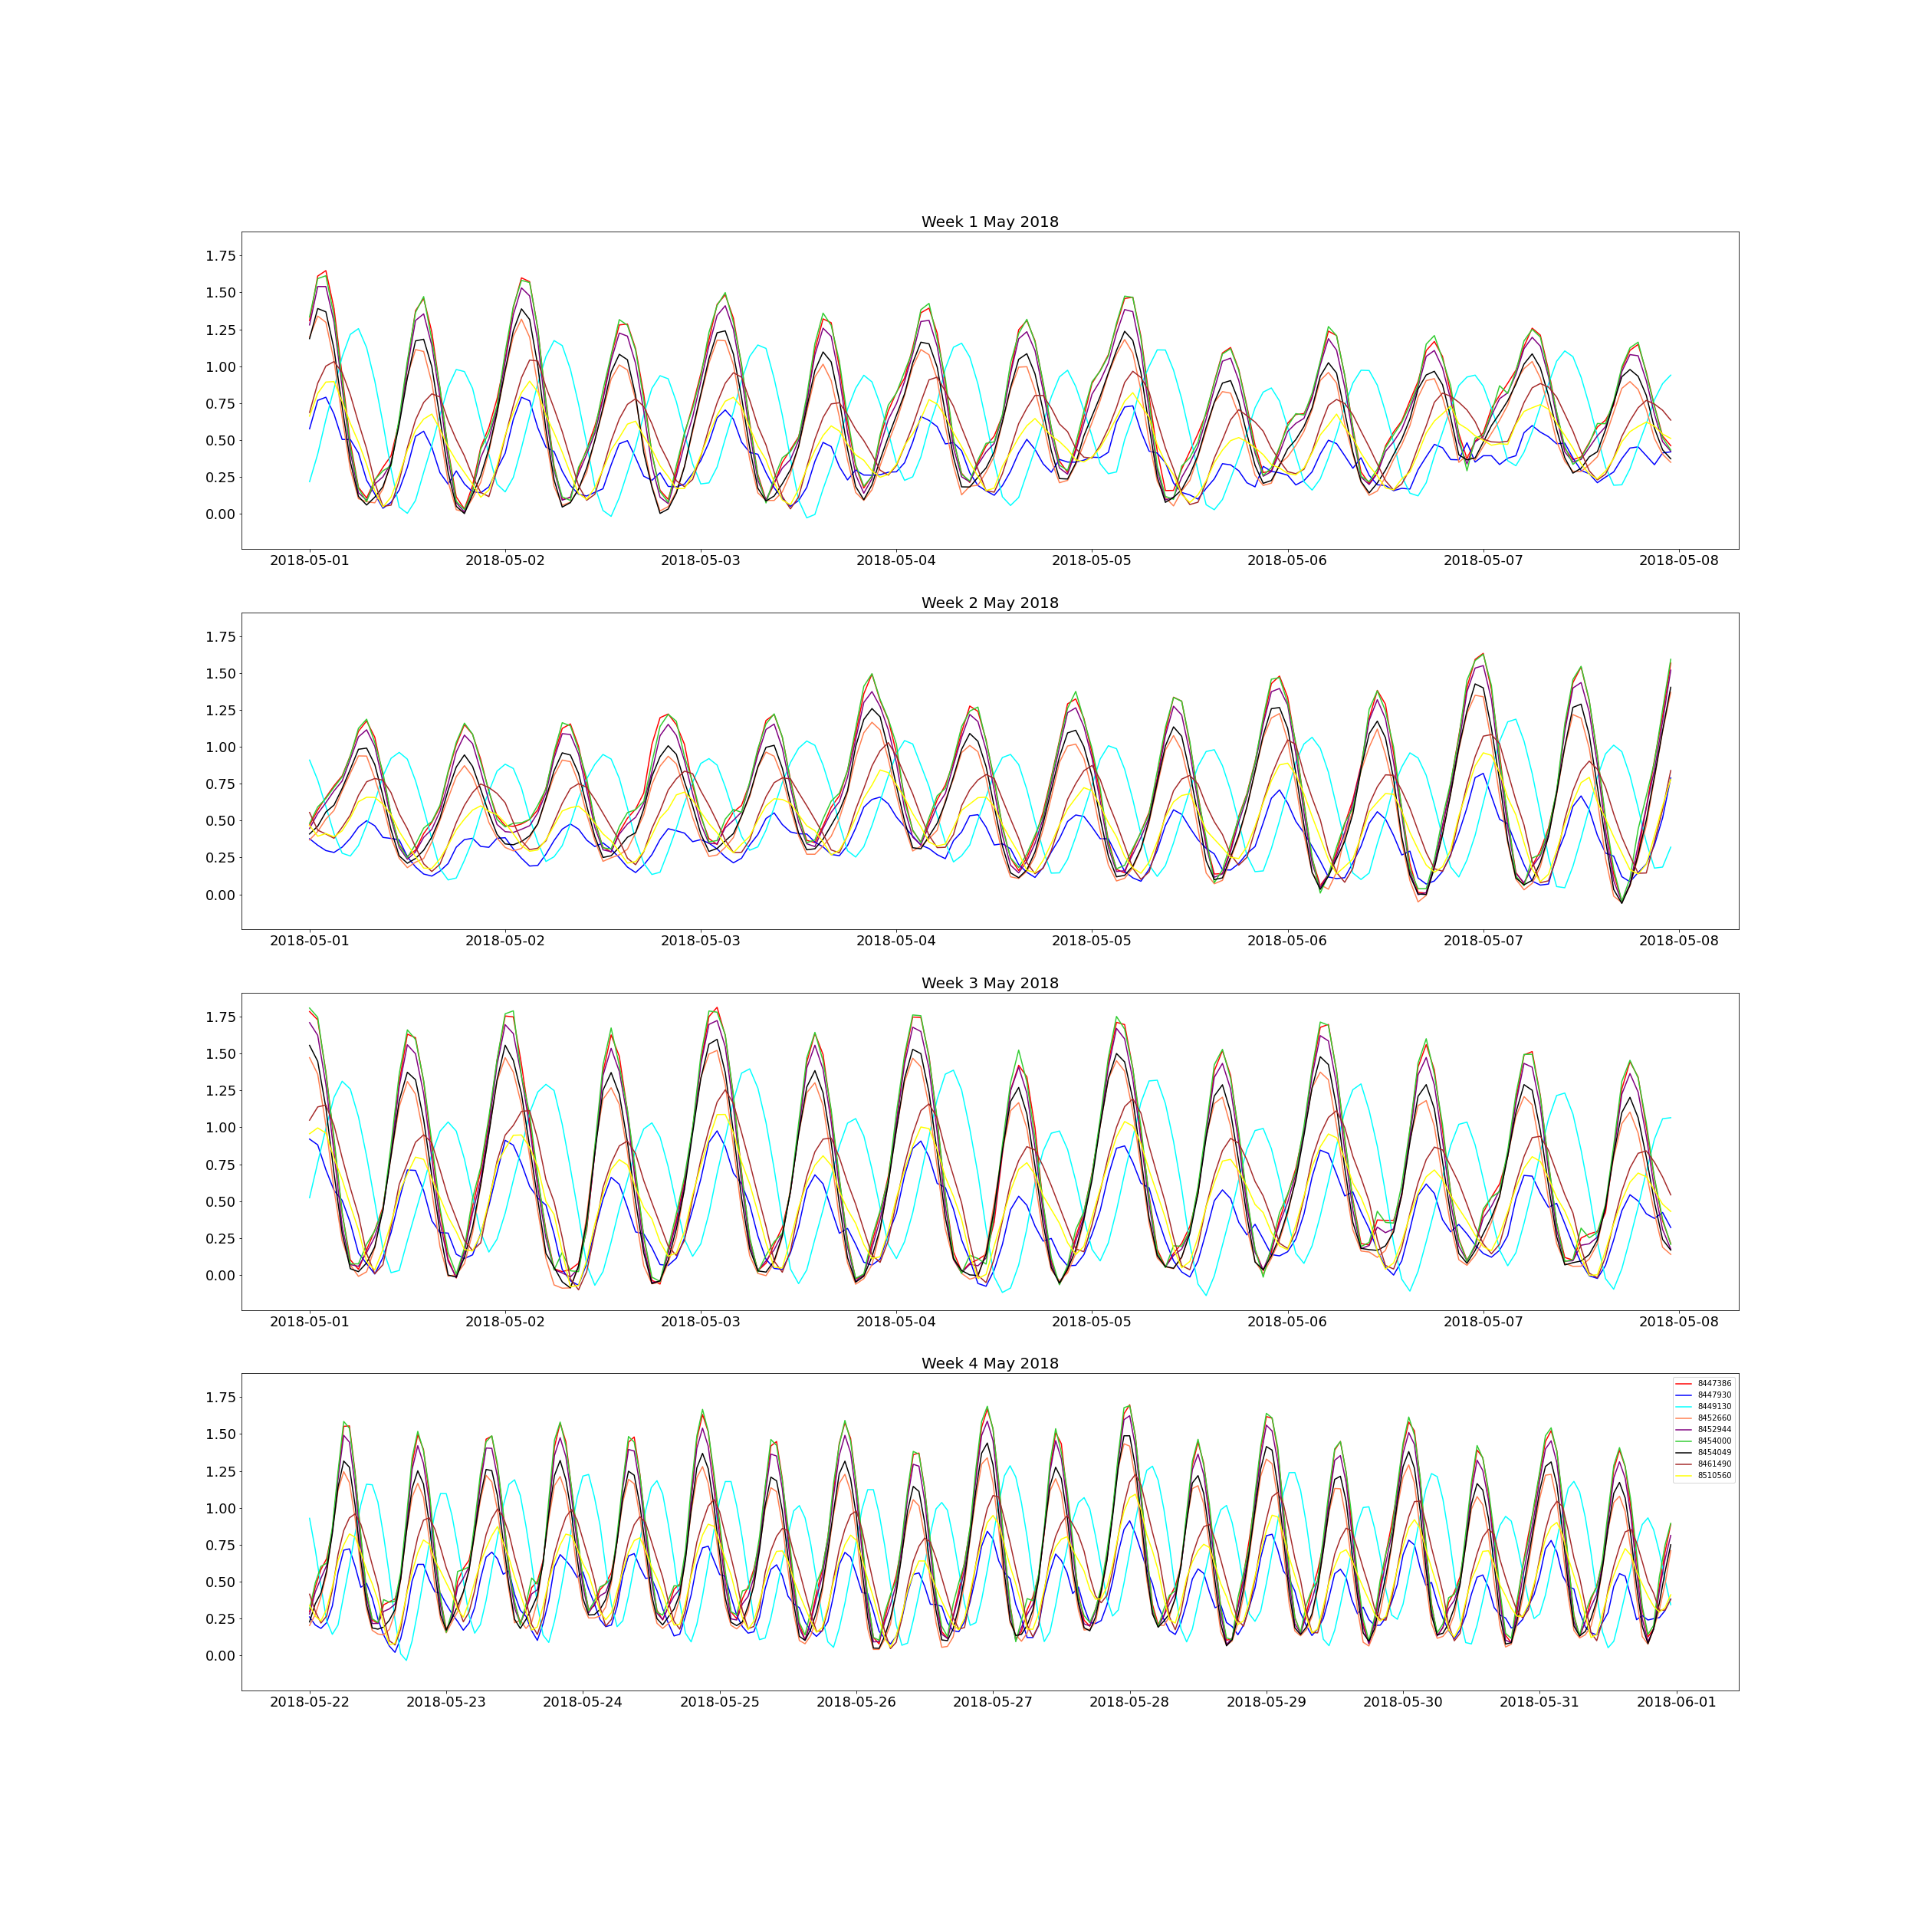

We can also make these weekly subplots, but compare the verified NOAA water level to the predicted NOAA water level. This would be interesting to see in the events of storms and heavy rain. There would be a large difference between the predicted and verified water level in such an event because the predicted ones do not predict storms. By comparing the two in a line graph, we can visualize the storm surge.

In [ ]:
def predictedvsverified(time, waterlevel_verified, waterlevel_predicted, year, month, title1, title2, title3, title4, file):
    #Create a list where it ends in only the year you want for predicted and verified data
    yr=[]
    yrp_level=[]
    yrv_level=[]
    for k in range(len(time)):
        if year in time[k]:
            yr.append(time[k])
            yrp_level.append(waterlevel_predicted[k])
            yrv_level.append(waterlevel_verified[k])
    #Creat a list where the first part of the string is the month you want to only get that month
    mmyr=[]
    mmyr_waterp_str=[]
    mmyr_waterv_str=[]
    for i in range(len(yr)):
        if yr[i].startswith(month):
            mmyr.append(yr[i])
            mmyr_waterp_str.append(yrp_level[i])
            mmyr_waterv_str.append(yrv_level[i])
    #Make weekly lists for that month of predicted and verified data
    week1_str=[]
    week1_waterp_str=[]
    week1_waterv_str=[]
    week2_str=[]
    week2_waterp_str=[]
    week2_waterv_str=[]
    week3_str=[]
    week3_waterp_str=[]
    week3_waterv_str=[]
    week4_str=[]
    week4_waterp_str=[]
    week4_waterv_str=[]
    for j in range(len(mmyr)):
        #Say that if the date contains these days in the middle, that is week one. So days 1 through 7
        if "/1/" in mmyr[j] or "/2/" in mmyr[j] or "/3/" in mmyr[j] or "/4/" in mmyr[j] or "/5/" in mmyr[j] or "/6/" in mmyr[j] or "/7/" in mmyr[j]:
            week1_str.append(mmyr[j])
            week1_waterp_str.append(mmyr_waterp_str[j])
            week1_waterv_str.append(mmyr_waterv_str[j])
        #Days 8 through 14 are week 2
        elif "/8/" in mmyr[j] or "/9/" in mmyr[j] or "/10/" in mmyr[j] or "/11/" in mmyr[j] or "/12/" in mmyr[j] or "/13/" in mmyr[j] or "/14/" in mmyr[j]:
            week2_str.append(mmyr[j])
            week2_waterp_str.append(mmyr_waterp_str[j])
            week2_waterv_str.append(mmyr_waterv_str[j])
        #Days 15 through 21 are week 3
        elif "/15/" in mmyr[j] or "/16/" in mmyr[j] or "/17/" in mmyr[j] or "/18/" in mmyr[j] or "/19/" in mmyr[j] or "/20/" in mmyr[j] or "/21/" in mmyr[j]:
            week3_str.append(mmyr[j])
            week3_waterp_str.append(mmyr_waterp_str[j])
            week3_waterv_str.append(mmyr_waterv_str[j])
        #Days 22 through 31 are week 4
        elif "/22/" in mmyr[j] or "/23/" in mmyr[j] or "/24/" in mmyr[j] or "/25/" in mmyr[j] or "/26/" in mmyr[j] or "/27/" in mmyr[j] or "/28/" in mmyr[j] or "/29/" in mmyr[j] or "/30/" in mmyr[j] or "/31/" in mmyr[j]:
            week4_str.append(mmyr[j])
            week4_waterp_str.append(mmyr_waterp_str[j])
            week4_waterv_str.append(mmyr_waterv_str[j])
    #Make the list of string dates into datetime
    week1=[]
    week2=[]
    week3=[]
    week4=[]
    for l in range(len(week1_str)):
        week1.append(datetime.strptime(week1_str[l], '%m/%d/%Y %H:%M'))
    for l in range(len(week2_str)):
        week2.append(datetime.strptime(week2_str[l], '%m/%d/%Y %H:%M'))
    for l in range(len(week3_str)):
        week3.append(datetime.strptime(week3_str[l], '%m/%d/%Y %H:%M'))
    for l in range(len(week4_str)):
        week4.append(datetime.strptime(week4_str[l], '%m/%d/%Y %H:%M'))
    #Make the list of weekly water level strings into floats
    week1_waterp=[]
    week2_waterp=[]
    week3_waterp=[]
    week4_waterp=[]
    week1_waterv=[]
    week2_waterv=[]
    week3_waterv=[]
    week4_waterv=[]
    for i in range(len(week1_waterp_str)):
        week1_waterp.append(float(week1_waterp_str[i]))
        week1_waterv.append(float(week1_waterv_str[i]))
    for i in range(len(week2_waterp_str)):
        week2_waterp.append(float(week2_waterp_str[i]))
        week2_waterv.append(float(week2_waterv_str[i]))
    for i in range(len(week3_waterp_str)):
        week3_waterp.append(float(week3_waterp_str[i]))
        week3_waterv.append(float(week3_waterv_str[i]))
    for i in range(len(week4_waterp_str)):
        week4_waterp.append(float(week4_waterp_str[i]))
        week4_waterv.append(float(week4_waterv_str[i]))
    #Making subplots. I want 4 vertical plots and for them to share a y-axis
    fig, axs=plt.subplots(4, figsize=(35,35), sharey = True)
    axs[0].plot(week1, week1_waterp, label="Predicted", color="lightpink")
    axs[0].plot(week1, week1_waterv, label="Verified", color="blue")
    axs[1].plot(week2, week2_waterp, label="Predicted", color="lightpink")
    axs[1].plot(week2, week2_waterv, label="Verified", color="blue")
    axs[2].plot(week3, week3_waterp, label="Predicted", color="lightpink")
    axs[2].plot(week3, week3_waterv, label="Verified", color="blue")
    axs[3].plot(week4, week4_waterp, label="Predicted", color="lightpink")
    axs[3].plot(week4, week4_waterv, label="Verified", color="blue")
    #Making title of each plot
    axs[0].set_title(title1, fontsize=20)
    axs[1].set_title(title2, fontsize=20)
    axs[2].set_title(title3, fontsize=20)
    axs[3].set_title(title4, fontsize=20)
    #Setting font of the axes
    axs[0].xaxis.set_tick_params(labelsize=18)
    axs[1].xaxis.set_tick_params(labelsize=18)
    axs[2].xaxis.set_tick_params(labelsize=18)
    axs[3].xaxis.set_tick_params(labelsize=18)
    axs[0].yaxis.set_tick_params(labelsize=18)
    axs[1].yaxis.set_tick_params(labelsize=18)
    axs[2].yaxis.set_tick_params(labelsize=18)
    axs[3].yaxis.set_tick_params(labelsize=18)
    plt.legend()
    #plt.show
    plt.savefig(file)
#Making plots of predicted versus verified water level during the month of Hurricane Henri for station 8510560
predictedvsverified(time_8510560, water_8510560, predicted_8510560, "/2021", "8/", "Hurricane Henri Week 1", "Hurricane Henri Week 2", "Hurricane Henri Week 3", "Hurricane Henri Week 4", "C:\\Users\\grace\\OneDrive\\Documents\\Brown_Data\\Tide_Plots\\Hurricane Henri 8510560.png")

The plot below is the result of that code. Hurricane Henri occurred towards the end of August 2018. You can see the verified water level is a lot higher than the predicted starting from August 28, 2021.
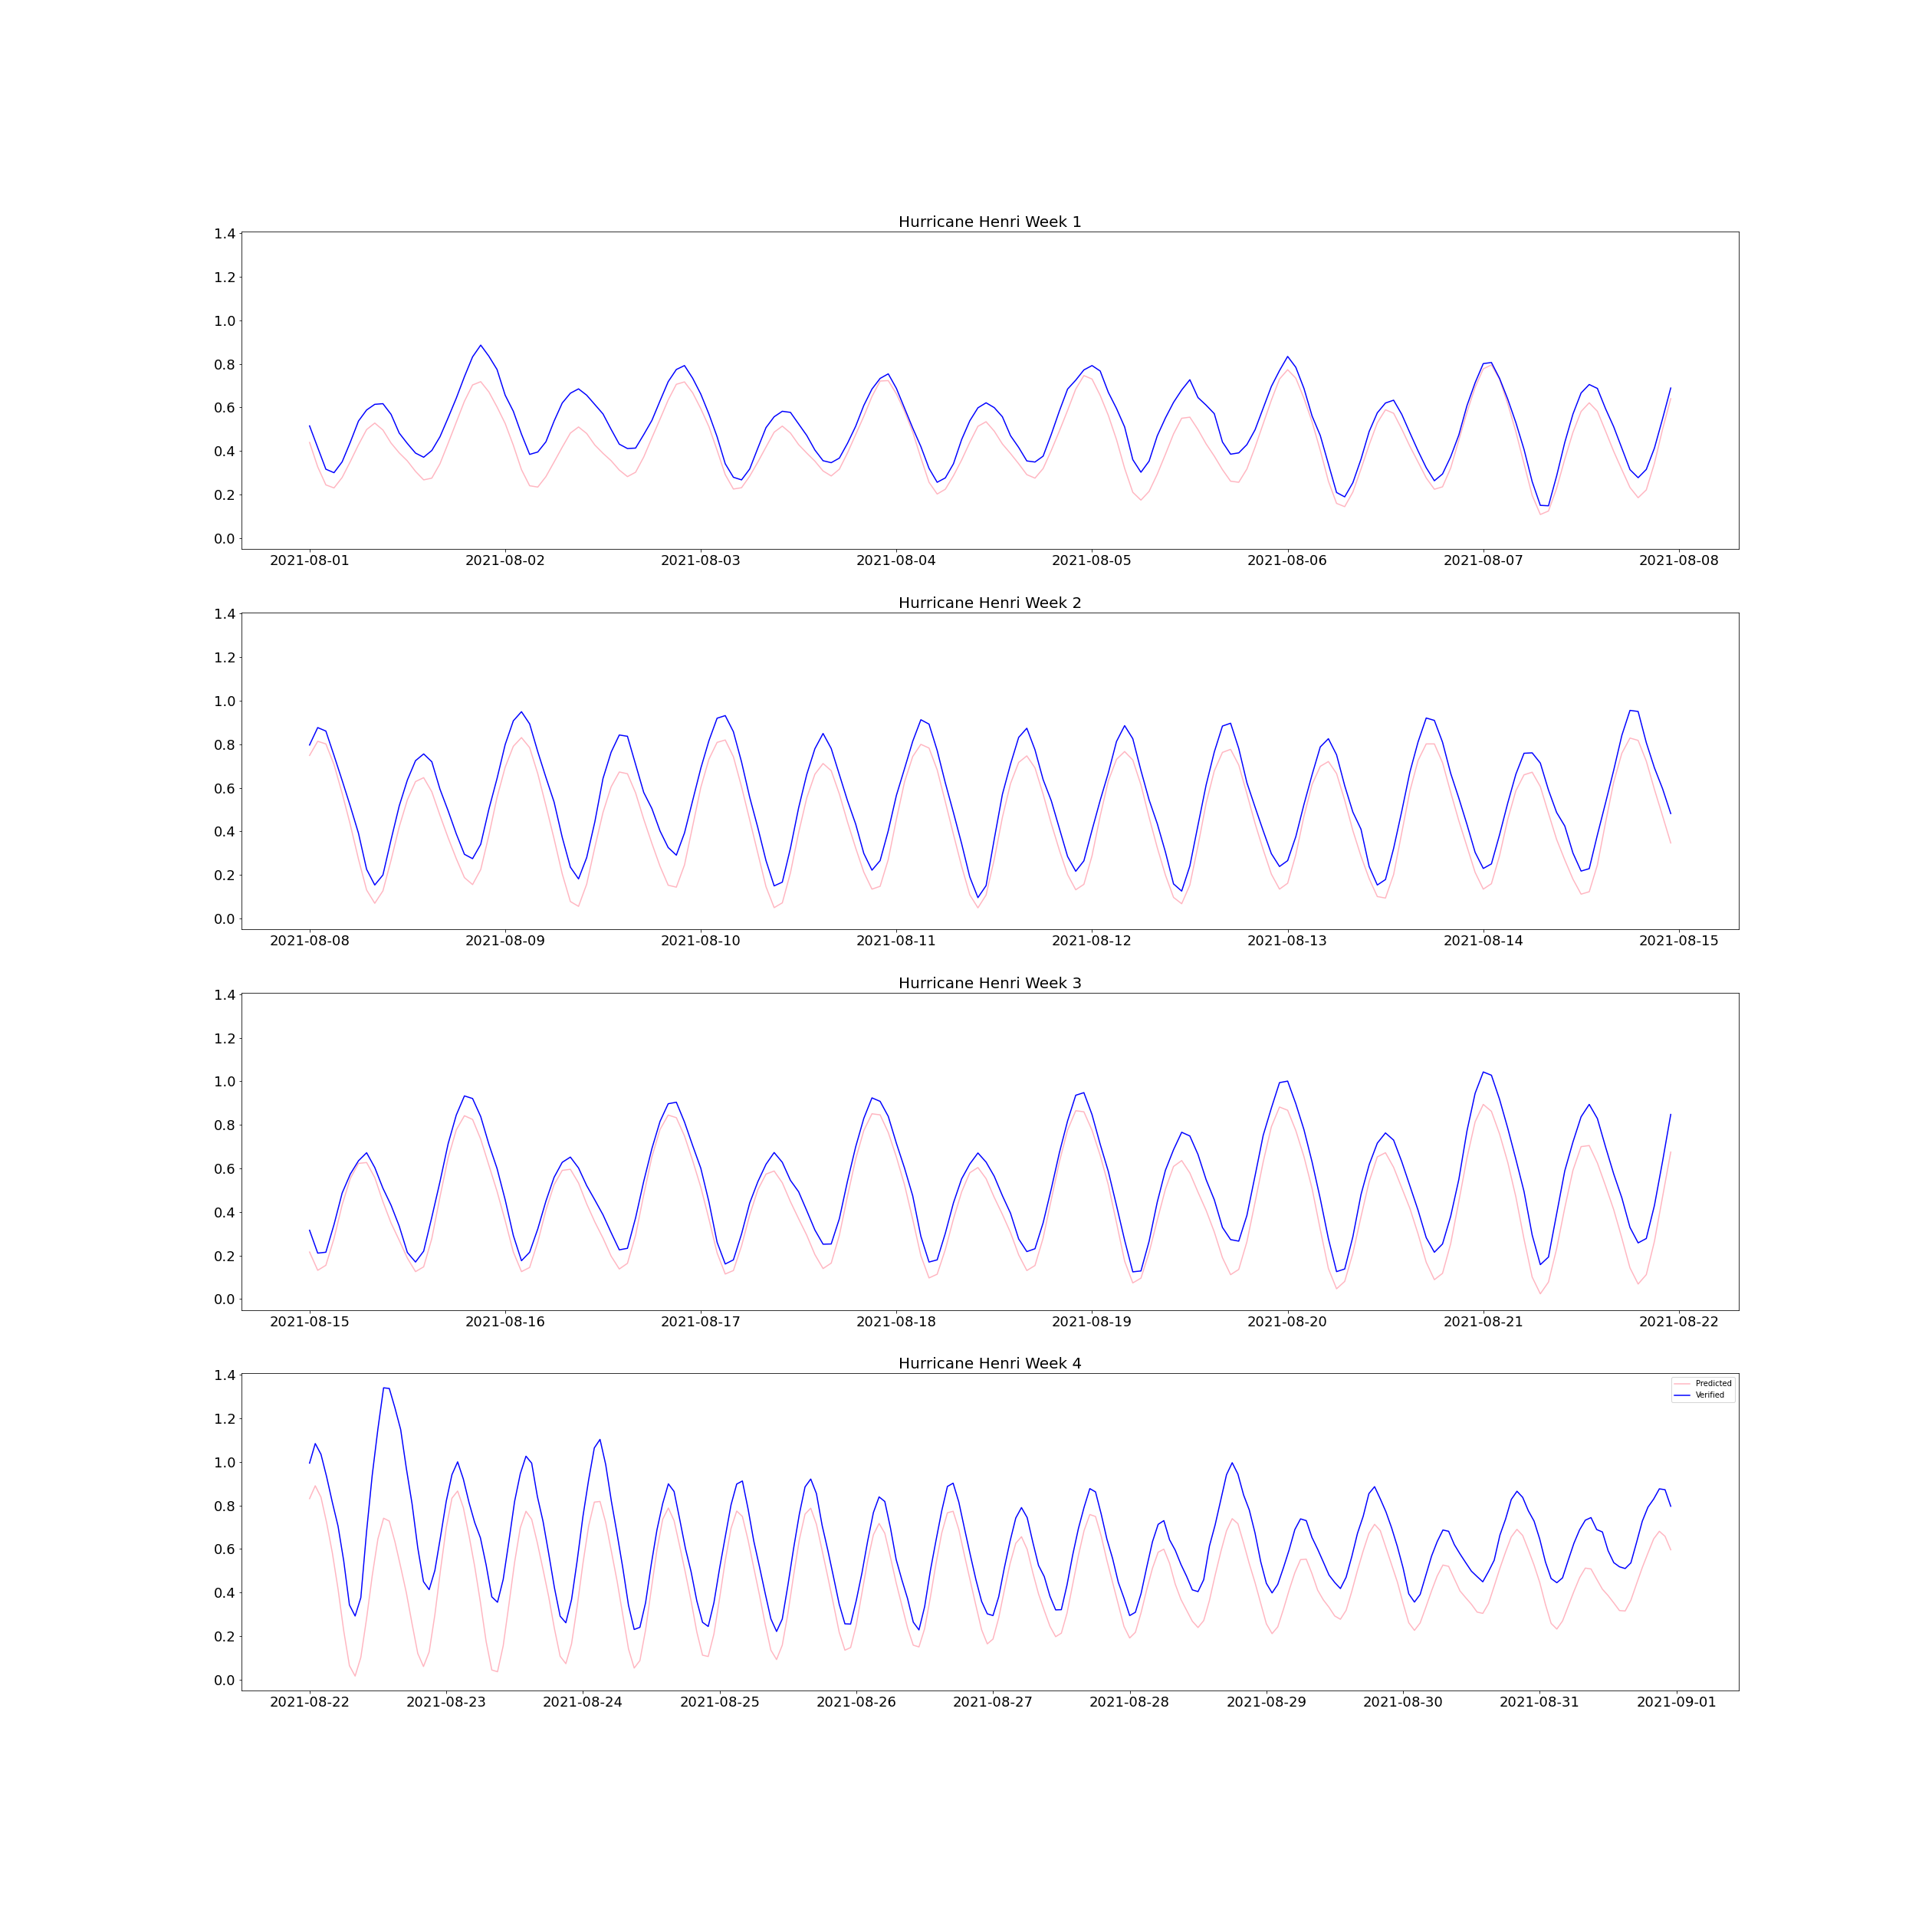

For the OSOM data, we are largely concerned with analyzing how accurately the model predicts the observed water level. The first step in this is to read in the OSOM data. This data is stored in a netCDF file, so it needs a different function than the comma-separated value data. We have two different versions of the OSOM water level data, version 000 and version 001. We must read in the files for each tide gauge location, and also for each version. Version 000 is based on NOAA 2003 tide data while version 001 is based on NOAA 2015 information.

In [ ]:
#"file" is the location of the netCDF files
def readnc(file):
    #Read in the netCDF file
    f=nc.Dataset(file)
    #Define the variabels we want, zeta and time
    zeta0 = f.variables['zeta']
    ocean_time = f.variables['ocean_time']
    #Read in the zeta variable
    Zeta=zeta0[:]
    #Reshape it so it is only 1 dimension and plottable
    Zeta=Zeta.reshape(-1,)
    #Turn the array into a list so it is easy to plot and manipulate
    zeta=Zeta.tolist()
    #Convert the time from seconds since 01-01-2017 to dates
    dates = num2date(ocean_time[:], ocean_time.units)
    return zeta, dates
#Read in the file for each station for version 000
zeta_8447930_000, date_8447930_000=readnc("C:\\Users\\grace\\OneDrive\\Documents\\Brown_Data\\OSOM_Tides\\Tides_000\\tide_BZBM3.nc")
zeta_8452944_000, date_8452944_000=readnc("C:\\Users\\grace\\OneDrive\\Documents\\Brown_Data\\OSOM_Tides\\Tides_000\\tide_CPTR1.nc")
zeta_8454000_000, date_8454000_000=readnc("C:\\Users\\grace\\OneDrive\\Documents\\Brown_Data\\OSOM_Tides\\Tides_000\\tide_FOXR1.nc")
zeta_8447386_000, date_8447386_000=readnc("C:\\Users\\grace\\OneDrive\\Documents\\Brown_Data\\OSOM_Tides\\Tides_000\\tide_FRVM3.nc")
zeta_8510560_000, date_8510560_000=readnc("C:\\Users\\grace\\OneDrive\\Documents\\Brown_Data\\OSOM_Tides\\Tides_000\\tide_MTKN6.nc")
zeta_8461490_000, date_8461490_000=readnc("C:\\Users\\grace\\OneDrive\\Documents\\Brown_Data\\OSOM_Tides\\Tides_000\\tide_NLNC3.nc")
zeta_8449130_000, date_8449130_000=readnc("C:\\Users\\grace\\OneDrive\\Documents\\Brown_Data\\OSOM_Tides\\Tides_000\\tide_NTKM3.nc")
zeta_8452660_000, date_8452660_000=readnc("C:\\Users\\grace\\OneDrive\\Documents\\Brown_Data\\OSOM_Tides\\Tides_000\\tide_NWPR1.nc")
zeta_8454049_000, date_8454049_000=readnc("C:\\Users\\grace\\OneDrive\\Documents\\Brown_Data\\OSOM_Tides\\Tides_000\\tide_QPTR1.nc")
#Read in the file for each station for version 001
zeta_8447930_001, date_8447930_001=readnc("C:\\Users\\grace\\OneDrive\\Documents\\Brown_Data\\OSOM_Tides\\Tides_001\\tide_BZBM3.nc")
zeta_8452944_001, date_8452944_001=readnc("C:\\Users\\grace\\OneDrive\\Documents\\Brown_Data\\OSOM_Tides\\Tides_001\\tide_CPTR1.nc")
zeta_8454000_001, date_8454000_001=readnc("C:\\Users\\grace\\OneDrive\\Documents\\Brown_Data\\OSOM_Tides\\Tides_001\\tide_FOXR1.nc")
zeta_8447386_001, date_8447386_001=readnc("C:\\Users\\grace\\OneDrive\\Documents\\Brown_Data\\OSOM_Tides\\Tides_001\\tide_FRVM3.nc")
zeta_8510560_001, date_8510560_001=readnc("C:\\Users\\grace\\OneDrive\\Documents\\Brown_Data\\OSOM_Tides\\Tides_001\\tide_MTKN6.nc")
zeta_8461490_001, date_8461490_001=readnc("C:\\Users\\grace\\OneDrive\\Documents\\Brown_Data\\OSOM_Tides\\Tides_001\\tide_NLNC3.nc")
zeta_8449130_001, date_8449130_001=readnc("C:\\Users\\grace\\OneDrive\\Documents\\Brown_Data\\OSOM_Tides\\Tides_001\\tide_NTKM3.nc")
zeta_8452660_001, date_8452660_001=readnc("C:\\Users\\grace\\OneDrive\\Documents\\Brown_Data\\OSOM_Tides\\Tides_001\\tide_NWPR1.nc")
zeta_8454049_001, date_8454049_001=readnc("C:\\Users\\grace\\OneDrive\\Documents\\Brown_Data\\OSOM_Tides\\Tides_001\\tide_QPTR1.nc")

The OSOM water level data is the average over an hour, not an instantaneous point. The NOAA data is an instantaneous measurement at that time. So, in order to compare the two, we need to average the NOAA data over an hour. For this purpose, we use the 6 minute data instead of the hourly data. The average is taken around the center of the hour. For example, the average of from 01:00 to 01:54. 

In [ ]:
def averages(time_noaa, waterlevel_noaa):
    time30=[]
    averagecenter=[]
    for i in range(len(time_noaa)):
        if "/2017" in time_noaa[i]:
            listcenter=[]
            if ":30" in time_noaa[i]:
                time30.append(time_noaa[i])
                listcenter.append(waterlevel_noaa[i-5])
                listcenter.append(waterlevel_noaa[i-4])
                listcenter.append(waterlevel_noaa[i-3])
                listcenter.append(waterlevel_noaa[i-2])
                listcenter.append(waterlevel_noaa[i-1])
                listcenter.append(waterlevel_noaa[i])
                listcenter.append(waterlevel_noaa[i+1])
                listcenter.append(waterlevel_noaa[i+2])
                listcenter.append(waterlevel_noaa[i+3])
                listcenter.append(waterlevel_noaa[i+4])
                averagecenter.append(np.nanmean(listcenter))
    return time30, averagecenter
#Read in the 6 minute interval csv files
time_8447386_avg, water_8447386_avg, predicted_8447386_avg = readcsv("C:\\Users\\grace\\OneDrive\\Documents\\Brown_Data\\Tides\\CO-OPS_8447386_average.csv")
time_8447930_avg, water_8447930_avg, predicted_8447930_avg = readcsv("C:\\Users\\grace\\OneDrive\\Documents\\Brown_Data\\Tides\\CO-OPS_8447930_average.csv")
time_8449130_avg, water_8449130_avg, predicted_8449130_avg = readcsv("C:\\Users\\grace\\OneDrive\\Documents\\Brown_Data\\Tides\\CO-OPS_8449130_average.csv")
time_8452660_avg, water_8452660_avg, predicted_8452660_avg = readcsv("C:\\Users\\grace\\OneDrive\\Documents\\Brown_Data\\Tides\\CO-OPS_8452660_average.csv")
time_8452944_avg, water_8452944_avg, predicted_8452944_avg = readcsv("C:\\Users\\grace\\OneDrive\\Documents\\Brown_Data\\Tides\\CO-OPS_8452944_average.csv")
time_8454000_avg, water_8454000_avg, predicted_8454000_avg = readcsv("C:\\Users\\grace\\OneDrive\\Documents\\Brown_Data\\Tides\\CO-OPS_8454000_average.csv")
time_8454049_avg, water_8454049_avg, predicted_8454049_avg = readcsv("C:\\Users\\grace\\OneDrive\\Documents\\Brown_Data\\Tides\\CO-OPS_8454049_average.csv")
time_8461490_avg, water_8461490_avg, predicted_8461490_avg = readcsv("C:\\Users\\grace\\OneDrive\\Documents\\Brown_Data\\Tides\\CO-OPS_8461490_average.csv")
time_8510560_avg, water_8510560_avg, predicted_8510560_avg = readcsv("C:\\Users\\grace\\OneDrive\\Documents\\Brown_Data\\Tides\\CO-OPS_8510560_average.csv")
#Call the function to make the lists of average values
time_8447386_30, water_8447386_center=averages(time_8447386_avg, water_8447386_avg)
time_8447930_30, water_8447930_center=averages(time_8447930_avg, water_8447930_avg)
time_8449130_30, water_8449130_center=averages(time_8449130_avg, water_8449130_avg)
time_8452660_30, water_8452660_center=averages(time_8452660_avg, water_8452660_avg)
time_8452944_30, water_8452944_center=averages(time_8452944_avg, water_8452944_avg)
time_8454000_30, water_8454000_center=averages(time_8454000_avg, water_8454000_avg)
time_8454049_30, water_8454049_center=averages(time_8454049_avg, water_8454049_avg)
time_8461490_30, water_8461490_center=averages(time_8461490_avg, water_8461490_avg)
time_8510560_30, water_8510560_center=averages(time_8510560_avg, water_8510560_avg)

To assess the accuracy of the model, we can make scatterplots where the observed water level values are on the x-axis and the modeled values are on the y-axis. Then we can see how close the data is to a one-to-one relationship. For this and all future analysis, a correction is made because the NOAA water level is calculated with respect to mean low low water, but OSOM is not. To account for this, we average both the NOAA water levels for that station in 2017 and the OSOM water levels. Then take the difference of the averages and add that to each value in the OSOM water level list. 

In [ ]:
#"average_noaa" is the list of NOAA water level data that we averaged over the hour
#"osom_000" is the OSOM version 000 water level list
#"osom_001" is the OSOM version 001 water level list
#"title"  is what you want to call the plot
#"path" is where you want to save the plot
def averagescatterplots(average_noaa, osom_000, osom_001, title, path):
    #Model 001 does not include 12/31/17, so delete the last 24 hours of the NOAA data
    average_noaa_001=[]
    for i in range(len(average_noaa)):
        average_noaa_001.append(average_noaa[i])
    del average_noaa_001[-24:]
    #Remove data that are nan values
    new_buoy_000 = []
    new_zeta_000=[]
    for i in range(len(average_noaa)):
        if str(average_noaa[i]) != 'nan':
            new_buoy_000.append(average_noaa[i])
            new_zeta_000.append(osom_000[i])
    new_buoy_001 = []
    new_zeta_001=[]
    for i in range(len(average_noaa_001)):
        if str(average_noaa_001[i]) != 'nan':
            new_buoy_001.append(average_noaa_001[i])
            new_zeta_001.append(osom_001[i])
    #Find the average of the NOAA data and the OSOM data
    average_noaa_000=sum(new_buoy_000)/len(new_buoy_000)
    average_osom_000=sum(new_zeta_000)/len(new_zeta_000)
    #NOAA data is taken with respect to MLLW and OSOM is not
    #To correct this difference, we will take the difference between the averages and add it to the OSOM data
    difference_000=average_noaa_000-average_osom_000
    corrected_000=[]
    for j in range(len(new_zeta_000)):
        corrected_000.append(new_zeta_000[j]+difference_000)
    average_noaa_001=sum(new_buoy_001)/len(new_buoy_001)
    average_osom_001=sum(new_zeta_001)/len(new_zeta_001)
    difference_001=average_noaa_001-average_osom_001
    corrected_001=[]
    for j in range(len(new_zeta_001)):
        corrected_001.append(new_zeta_001[j]+difference_001)
    #Now make the scatterplot. Two subplots to compare side-by-side
    fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)
    axes[0].scatter(new_buoy_000, corrected_000)
    xpoints_000 = ypoints_000 = plt.xlim()
    #This is line y=x
    axes[0].plot(xpoints_000, ypoints_000, color='k', lw=3, scalex=False, scaley=False)
    #This is the slope of the scatter points
    axes[0].plot(np.unique(new_buoy_000), np.poly1d(np.polyfit(new_buoy_000, corrected_000, 1))(np.unique(new_buoy_000)), linestyle='--', lw=3, color='red')
    axes[1].scatter(new_buoy_001, corrected_001)
    xpoints_001 = ypoints_001 = plt.xlim()
    #This is line y=x
    axes[1].plot(xpoints_001, ypoints_001, color='k', lw=3, scalex=False, scaley=False)
    #This is the slope of the scatter points
    axes[1].plot(np.unique(new_buoy_001), np.poly1d(np.polyfit(new_buoy_001, corrected_001, 1))(np.unique(new_buoy_001)), linestyle='--', lw=3, color='red')
    axes[0].set_title("000")
    axes[1].set_title("001")
    fig.text(0.5, 0.04, 'Observed Water Level (m)', ha='center', va='center')
    fig.text(0.06, 0.5, 'Modeled Water Level (m)', ha='center', va='center', rotation='vertical')
    plt.suptitle(title)
    plt.savefig(path)    

The plot below is an example for station 8447930. The black line represents a perfect one-to-one relationship. The red dotted line represents the actual line of best fit. We can see that the two do not match, for either version of the model. This hints towards necessary corrections. 
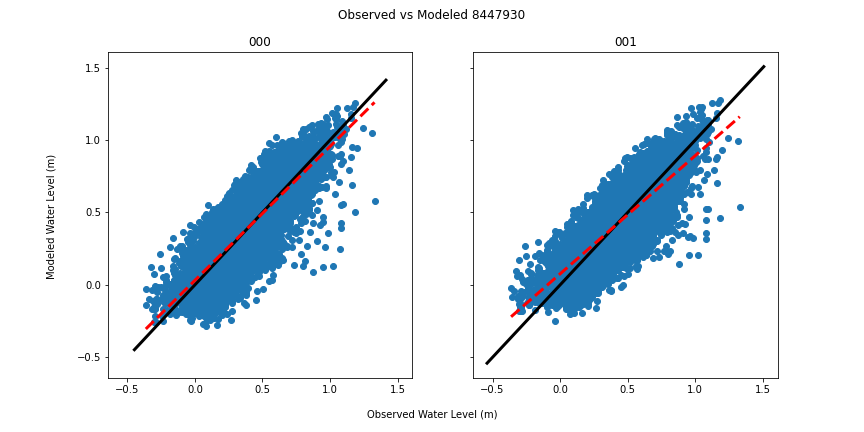

To quantify how much each station should be corrected, we can calculate scale (slope), bias (intercept), and standard error. For scale and slope, we use a function that already exists in numpy. For the standard error, we calculate two types: raw and corrected. The raw standard error is the error of the difference between the observed and modeled water level. The corrected standard error is the error of the difference between the observed water level and the modeled water level multiplied by scale and added by bias. According to these values, it was found overall that Modeled = (86%-96%)* +/- (15%-18%). The code to find these values is below.

In [ ]:
#Make a function to return slope and intercepts of the lines and compare
#"average_noaa" is the list of NOAA water level data that we averaged over the hour
#"osom_000" is the OSOM version 000 water level list
#"osom_001" is the OSOM version 001 water level list
def slope(average_noaa, osom_000, osom_001):
    #Model 001 does not include 12/31/17, so delete the last 24 hours of the NOAA data
    average_noaa_001=[]
    for i in range(len(average_noaa)):
        average_noaa_001.append(average_noaa[i])
    del average_noaa_001[-24:]
    #Remove data that are nan values
    new_buoy_000 = []
    new_zeta_000=[]
    for i in range(len(average_noaa)):
        if str(average_noaa[i]) != 'nan':
            new_buoy_000.append(average_noaa[i])
            new_zeta_000.append(osom_000[i])
    new_buoy_001 = []
    new_zeta_001=[]
    for i in range(len(average_noaa_001)):
        if str(average_noaa_001[i]) != 'nan':
            new_buoy_001.append(average_noaa_001[i])
            new_zeta_001.append(osom_001[i])
    #Find the average of the NOAA data and the OSOM data
    average_noaa_000=sum(new_buoy_000)/len(new_buoy_000)
    average_osom_000=sum(new_zeta_000)/len(new_zeta_000)
    #NOAA data is taken with respect to MLLW and OSOM is not
    #To correct this difference, we will take the difference between the averages and add it to the OSOM data
    difference_000=average_noaa_000-average_osom_000
    corrected_000=[]
    for j in range(len(new_zeta_000)):
        corrected_000.append(new_zeta_000[j]+difference_000)
    average_noaa_001=sum(new_buoy_001)/len(new_buoy_001)
    average_osom_001=sum(new_zeta_001)/len(new_zeta_001)
    difference_001=average_noaa_001-average_osom_001
    corrected_001=[]
    for j in range(len(new_zeta_001)):
        corrected_001.append(new_zeta_001[j]+difference_001)
    slope_000, intercept_000 = np.polyfit(new_buoy_000,corrected_000,1)
    slope_001, intercept_001 = np.polyfit(new_buoy_001,corrected_001,1)
    return slope_000, slope_001, intercept_000, intercept_001
#Calculate the slope of the scatter plots at each station for center average
#slope_000_8447386, slope_001_8447386, int_000_8447386, int_001_8447386=slope(water_8447386_center, zeta_8447386_000, zeta_8447386_001)
slope_000_8447930, slope_001_8447930, int_000_8447930, int_001_8447930=slope(water_8447930_center, zeta_8447930_000, zeta_8447930_001)
#slope_000_8449130, slope_001_8449130, int_000_8449130, int_001_8449130=slope(water_8449130_center, zeta_8449130_000, zeta_8449130_001)
slope_000_8452660, slope_001_8452660, int_000_8452660, int_001_8452660=slope(water_8452660_center, zeta_8452660_000, zeta_8452660_001)
slope_000_8452944, slope_001_8452944, int_000_8452944, int_001_8452944=slope(water_8452944_center, zeta_8452944_000, zeta_8452944_001)
slope_000_8454000, slope_001_8454000, int_000_8454000, int_001_8454000=slope(water_8454000_center, zeta_8454000_000, zeta_8454000_001)
slope_000_8454049, slope_001_8454049, int_000_8454049, int_001_8454049=slope(water_8454049_center, zeta_8454049_000, zeta_8454049_001)
slope_000_8461490, slope_001_8461490, int_000_8461490, int_001_8461490=slope(water_8461490_center, zeta_8461490_000, zeta_8461490_001)
slope_000_8510560, slope_001_8510560, int_000_8510560, int_001_8510560=slope(water_8510560_center, zeta_8510560_000, zeta_8510560_001)
print("Slope 000 is", slope_000_8447930, slope_000_8452660, slope_000_8452944, slope_000_8454000, slope_000_8454049, slope_000_8461490, slope_000_8510560)
print("Slope 001 is", slope_001_8447930, slope_001_8452660, slope_001_8452944, slope_001_8454000, slope_001_8454049, slope_001_8461490, slope_001_8510560)
print("Intercept 000 is", int_000_8447930, int_000_8452660, int_000_8452944, int_000_8454000, int_000_8454049, int_000_8461490, int_000_8510560)
print("Intercept 001 is", int_001_8447930, int_001_8452660, int_001_8452944, int_001_8454000, int_001_8454049, int_001_8461490, int_001_8510560)

In [ ]:
#Write a function to return the raw standard deviation of the difference between observed and modeled data
def rawstdev(average_noaa, osom_000,osom_001):
    #Model 001 does not include 12/31/17, so delete the last 24 hours of the NOAA data
    average_noaa_001=[]
    for i in range(len(average_noaa)):
        average_noaa_001.append(average_noaa[i])
    del average_noaa_001[-24:]
    #Remove data that are nan values
    new_buoy_000 = []
    new_zeta_000 = []
    for i in range(len(average_noaa)):
        if str(average_noaa[i]) != 'nan':
            new_buoy_000.append(average_noaa[i])
            new_zeta_000.append(osom_000[i])
    new_buoy_001 = []
    new_zeta_001=[]
    for i in range(len(average_noaa_001)):
        if str(average_noaa_001[i]) != 'nan':
            new_buoy_001.append(average_noaa_001[i])
            new_zeta_001.append(osom_001[i])
    #Find the average of the NOAA data and the OSOM data
    average_noaa_000=np.nanmean(new_buoy_000)
    average_osom_000=np.nanmean(new_zeta_000)
    #NOAA data is taken with respect to MLLW and OSOM is not
    #To correct this difference, we will take the difference between the averages and add it to the OSOM data
    difference_000=average_noaa_000-average_osom_000
    corrected_000=[]
    for j in range(len(new_zeta_000)):
        corrected_000.append(new_zeta_000[j]+difference_000)
    average_noaa_001=np.nanmean(new_buoy_001)
    average_osom_001=np.nanmean(new_zeta_001)
    difference_001=average_noaa_001-average_osom_001
    corrected_001=[]
    for j in range(len(new_zeta_001)):
        corrected_001.append(new_zeta_001[j]+difference_001)
    #Calculate the differences of the observed vs modeled data for 000
    differencelist_000=[]
    for i in range(len(new_buoy_000)):
        differencelist_000.append(new_buoy_000[i]-corrected_000[i])
    #Calculate the differences of the observed vs modeled data 001
    differencelist_001=[]
    for k in range(len(new_buoy_001)):
        differencelist_001.append(new_buoy_001[k]-corrected_001[k])
    stdev_000=np.std(differencelist_000)
    stdev_001=np.std(differencelist_001)
    var_000=np.var(differencelist_000)
    var_001=np.var(differencelist_001)
    return stdev_000, stdev_001, var_000, var_001 
#Calculate the raw standard error
#stdev_8447386_000, stdev_8447386_001, var_8447386_000, var_8447386_001=rawstdev(water_8447386_center, zeta_8447386_000, zeta_8447386_001)
stdev_8447930_000, stdev_8447930_001, var_8447930_000, var_8447930_001=rawstdev(water_8447930_center, zeta_8447930_000, zeta_8447930_001)
#stdev_8449130_000, stdev_8449130_001, var_8449130_000, var_8449130_001=rawstdev(water_8449130_center, zeta_8449130_000, zeta_8449130_001)
stdev_8452660_000, stdev_8452660_001, var_8452660_000, var_8452660_001=rawstdev(water_8452660_center, zeta_8452660_000, zeta_8452660_001)
stdev_8452944_000, stdev_8452944_001, var_8452944_000, var_8452944_001=rawstdev(water_8452944_center, zeta_8452944_000, zeta_8452944_001)
stdev_8454000_000, stdev_8454000_001, var_8454000_000, var_8454000_001=rawstdev(water_8454000_center, zeta_8454000_000, zeta_8454000_001)
stdev_8454049_000, stdev_8454049_001, var_8454049_000, var_8454049_001=rawstdev(water_8454049_center, zeta_8454049_000, zeta_8454049_001)
stdev_8461490_000, stdev_8461490_001, var_8461490_000, var_8461490_001=rawstdev(water_8461490_center, zeta_8461490_000, zeta_8461490_001)
stdev_8510560_000, stdev_8510560_001, var_8510560_000, var_8510560_001=rawstdev(water_8510560_center, zeta_8510560_000, zeta_8510560_001)
print("Raw deviation 000 is", stdev_8447930_000, stdev_8452660_000, stdev_8452944_000, stdev_8454000_000, stdev_8454049_000, stdev_8461490_000, stdev_8510560_000)
print("Raw deviation 001 is", stdev_8447930_001, stdev_8452660_001, stdev_8452944_001, stdev_8454000_001, stdev_8454049_001, stdev_8461490_001, stdev_8510560_001)
print("Raw variance 000 is", var_8447930_000, var_8452660_000, var_8452944_000, var_8454000_000, var_8454049_000, var_8461490_000, var_8510560_000)
print("Raw variance 001 is", var_8447930_001, var_8452660_001, var_8452944_001, var_8454000_001, var_8454049_001, var_8461490_001, var_8510560_001)
#Write a function for the corrected standard deviation
def correctedstdev(average_noaa, osom_000, osom_001):
    #Model 001 does not include 12/31/17, so delete the last 24 hours of the NOAA data
    average_noaa_001=[]
    for i in range(len(average_noaa)):
        average_noaa_001.append(average_noaa[i])
    del average_noaa_001[-24:]
    #Remove data that are nan values
    new_buoy_000 = []
    new_zeta_000=[]
    for i in range(len(average_noaa)):
        if str(average_noaa[i]) != 'nan':
            new_buoy_000.append(average_noaa[i])
            new_zeta_000.append(osom_000[i])
    new_buoy_001 = []
    new_zeta_001=[]
    for i in range(len(average_noaa_001)):
        if str(average_noaa_001[i]) != 'nan':
            new_buoy_001.append(average_noaa_001[i])
            new_zeta_001.append(osom_001[i])
    #Find the average of the NOAA data and the OSOM data
    average_noaa_000=np.nanmean(new_buoy_000)
    average_osom_000=np.nanmean(new_zeta_000)
    #NOAA data is taken with respect to MLLW and OSOM is not
    #To correct this difference, we will take the difference between the averages and add it to the OSOM data
    difference_000=average_noaa_000-average_osom_000
    corrected_000=[]
    for j in range(len(new_zeta_000)):
        corrected_000.append(new_zeta_000[j]+difference_000)
    average_noaa_001=np.nanmean(new_buoy_001)
    average_osom_001=np.nanmean(new_zeta_001)
    difference_001=average_noaa_001-average_osom_001
    corrected_001=[]
    for j in range(len(new_zeta_001)):
        corrected_001.append(new_zeta_001[j]+difference_001)
    slope_000, intercept_000 = np.polyfit(corrected_000,new_buoy_000,1)
    slope_001, intercept_001 = np.polyfit(corrected_001,new_buoy_001,1)
    fit_000=[]
    for i in range(len(corrected_000)):
        fit_000.append((slope_000*corrected_000[i])+intercept_000)
    fit_001=[]
    for i in range(len(corrected_001)):
        fit_001.append((slope_001*corrected_001[i])+intercept_001)
    differencelist_000=[]
    for k in range(len(new_buoy_000)):
        differencelist_000.append(new_buoy_000[k]-fit_000[k])
    differencelist_001=[]
    for k in range(len(new_buoy_001)):
        differencelist_001.append(new_buoy_001[k]-fit_001[k])
    stdev_000=np.std(differencelist_000)
    stdev_001=np.std(differencelist_001)
    var_000=np.var(differencelist_000)
    var_001=np.var(differencelist_001)
    return stdev_000, stdev_001, var_000, var_001
#fitdev_8447386_000, fitdev_8447386_001, fitvar_8447386_000, fitvar_8447386_001=correctedstdev(water_8447386_center, zeta_8447386_000, zeta_8447386_001)
fitdev_8447930_000, fitdev_8447930_001, fitvar_8447930_000, fitvar_8447930_001=correctedstdev(water_8447930_center, zeta_8447930_000, zeta_8447930_001)
#fitdev_8449130_000, fitdev_8449130_001, fitvar_8449130_000, fitvar_8449130_001=correctedstdev(water_8449130_center, zeta_8449130_000, zeta_8449130_001)
fitdev_8452660_000, fitdev_8452660_001, fitvar_8452660_000, fitvar_8452660_001=correctedstdev(water_8452660_center, zeta_8452660_000, zeta_8452660_001)
fitdev_8452944_000, fitdev_8452944_001, fitvar_8452944_000, fitvar_8452944_001=correctedstdev(water_8452944_center, zeta_8452944_000, zeta_8452944_001)
fitdev_8454000_000, fitdev_8454000_001, fitvar_8454000_000, fitvar_8454000_001=correctedstdev(water_8454000_center, zeta_8454000_000, zeta_8454000_001)
fitdev_8454049_000, fitdev_8454049_001, fitvar_8454049_000, fitvar_8454049_001=correctedstdev(water_8454049_center, zeta_8454049_000, zeta_8454049_001)
fitdev_8461490_000, fitdev_8461490_001, fitvar_8461490_000, fitvar_8461490_001=correctedstdev(water_8461490_center, zeta_8461490_000, zeta_8461490_001)
fitdev_8510560_000, fitdev_8510560_001, fitvar_8510560_000, fitvar_8510560_001=correctedstdev(water_8510560_center, zeta_8510560_000, zeta_8510560_001)
print("Fitted deviation 000 is", fitdev_8447930_000, fitdev_8452660_000, fitdev_8452944_000, fitdev_8454000_000, fitdev_8454049_000, fitdev_8461490_000, fitdev_8510560_000)
print("Fitted deviation 001 is", fitdev_8447930_001, fitdev_8452660_001, fitdev_8452944_001, fitdev_8454000_001, fitdev_8454049_001, fitdev_8461490_001, fitdev_8510560_001)
print("Fitted variance 000 is", fitvar_8447930_000, fitvar_8452660_000, fitvar_8452944_000, fitvar_8454000_000, fitvar_8454049_000, fitvar_8461490_000, fitvar_8510560_000)
print("Fitted variance 001 is", fitvar_8447930_001, fitvar_8452660_001, fitvar_8452944_001, fitvar_8454000_001, fitvar_8454049_001, fitvar_8461490_001, fitvar_8510560_001)

Once these statistical values are organized into a table, the values for version 000 look like this.
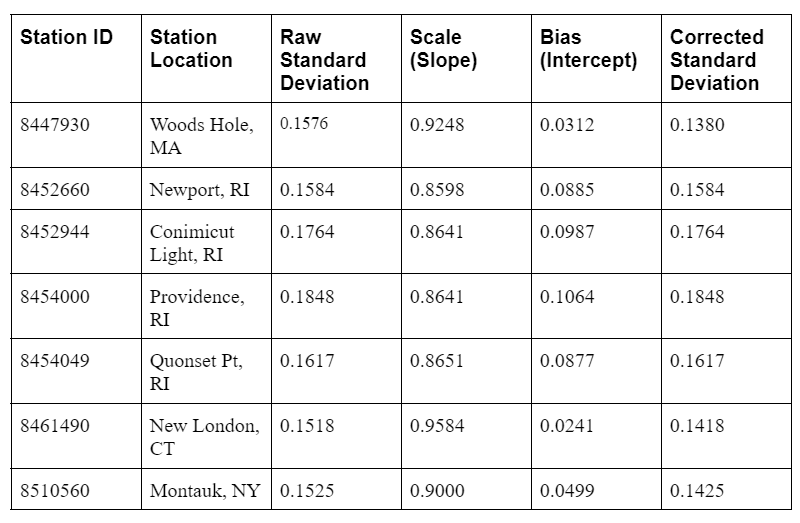

The values for 001 look like this.
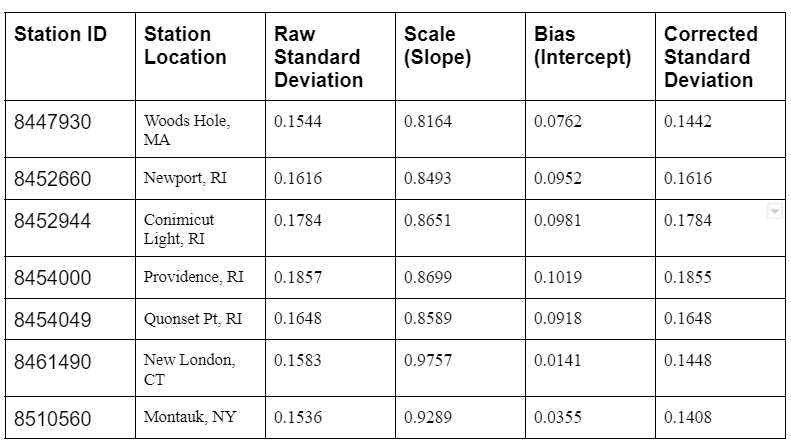
Overall, the corrected standard error is lower than the raw standard error which means we can empirically and linearly use bias and slope to improve the accuracy of OSOM tide predictions. Also, whether model 000 or 001 is more accurate varies from station to station, which should be looked into further to determine why.

We can use a bar graph to visually represent the the values in the table above. This will allow us to more easily see which stations have the highest raw standard error, how much the corrected standard error lowers, and more.

In [ ]:
#Create dataframe of standard error data
df = pd.DataFrame([['Raw Deviation 000', stdev_8447930_000, stdev_8452660_000, stdev_8452944_000, stdev_8454000_000, stdev_8454049_000, stdev_8461490_000, stdev_8510560_000], 
                   ['Raw Deviation 001', stdev_8447930_001, stdev_8452660_001, stdev_8452944_001, stdev_8454000_001, stdev_8454049_001, stdev_8461490_001, stdev_8510560_001], 
                   ['Corrected Deviation 000', fitdev_8447930_000, fitdev_8452660_000, fitdev_8452944_000, fitdev_8454000_000, fitdev_8454049_000, fitdev_8461490_000, fitdev_8510560_000],
                   ['Corrected Deviation 001', fitdev_8447930_001, fitdev_8452660_001, fitdev_8452944_001, fitdev_8454000_001, fitdev_8454049_001, fitdev_8461490_001, fitdev_8510560_001]],
                  columns=['Station Location', 'Woods Hole, MA', 'Newport, RI', 'Conimicut Light, RI', 'Providence, RI', 'Quonset Pt, RI', 'New London, CT', 'Montauk, NY'])

  
# Plot grouped bar chart
df.plot(x='Station Location',
        kind='bar',
        stacked=False,
        title='Standard Deviations of the Stations',
        figsize=[10,5],
        rot=10)
#Change legend location
plt.legend(loc='lower right')

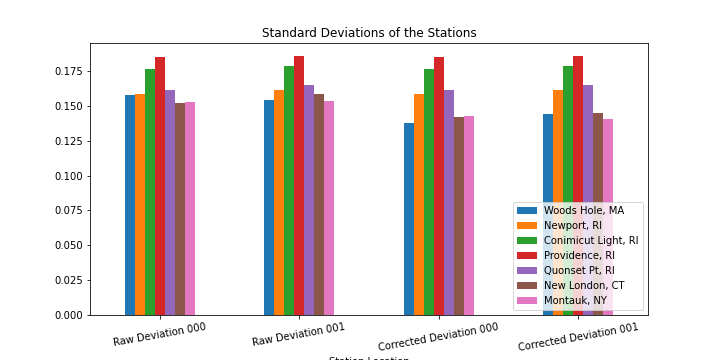